In [9]:

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   

import ablation_utils.uncertainty as uncertainty
import ablation_utils.data as datautils

import numpy as np
import pandas as pd
import matplotlib as plt


In [28]:

from sklearn.ensemble import RandomForestRegressor

# 1. load data
data = datautils.bike_sharing(eu_interval=[0, 1, 2, 3, 4, 5, 12, 13, 14, 15, 16, 17], eu_keep=0.03, seed=0)
dataname="bike_sharing"

# standardize y with TRAIN stats, so lambda means the same thing across datasets
mu, sd = data.y_train.mean(), data.y_train.std()
X_train, y_train = data.X_train, (data.y_train - mu) / sd
X_calib, y_calib = data.X_calib, (data.y_calib - mu) / sd
X_test,  y_test  = data.X_test,  (data.y_test  - mu) / sd
EU_test = data.group_test == "eu"

# 2. fit base model
model = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=0)
model.fit(X_train, y_train)
S_calib = np.abs(model.predict(X_calib) - y_calib)
S_test  = np.abs(model.predict(X_test)  - y_test)

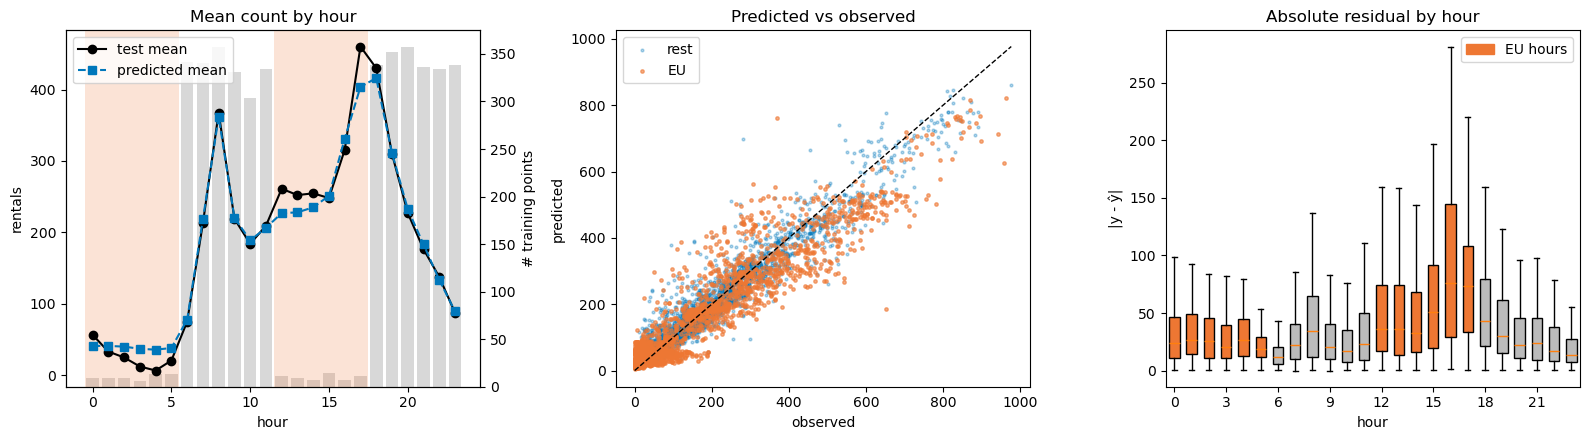

rest  MAE    33.3   R² 0.917   n 2495
EU    MAE    46.9   R² 0.872   n 2505


In [26]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# hour column: the only feature taking exactly the values 0..23
hour_col = [j for j in range(X_test.shape[1]) if set(np.unique(X_test[:, j])) == set(range(24))]
assert len(hour_col) == 1, hour_col
h_train, h_test = X_train[:, hour_col[0]].astype(int), X_test[:, hour_col[0]].astype(int)

y_hat = model.predict(X_test) * sd + mu          # back to rental counts
y_obs = y_test * sd + mu
res   = np.abs(y_obs - y_hat)
hours = np.arange(24)
eu_h  = sorted(set(h_test[EU_test]))

fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. mean count per hour + training points per hour
ax = axs[0]
for h in eu_h:
    ax.axvspan(h - 0.5, h + 0.5, color="#ee7733", alpha=0.2, lw=0)
ax.plot(hours, [y_obs[h_test == h].mean() for h in hours], "o-", color="black", label="test mean")
ax.plot(hours, [y_hat[h_test == h].mean() for h in hours], "s--", color="#0077bb", label="predicted mean")
ax2 = ax.twinx()
ax2.bar(hours, np.bincount(h_train, minlength=24), color="grey", alpha=0.3, width=0.8)
ax2.set_ylabel("# training points")
ax.set_zorder(ax2.get_zorder() + 1); ax.patch.set_visible(False)
ax.set_xlabel("hour"); ax.set_ylabel("rentals"); ax.set_title("Mean count by hour")
ax.legend(loc="upper left", frameon=True)

# 2. predicted vs observed, EU highlighted
ax = axs[1]
ax.scatter(y_obs[~EU_test], y_hat[~EU_test], s=4, alpha=0.3, color="#0077bb", label="rest")
ax.scatter(y_obs[EU_test],  y_hat[EU_test],  s=6, alpha=0.6, color="#ee7733", label="EU")
lim = [0, max(y_obs.max(), y_hat.max())]
ax.plot(lim, lim, "k--", lw=1)
ax.set_xlabel("observed"); ax.set_ylabel("predicted"); ax.set_title("Predicted vs observed")
ax.legend(frameon=True)

# 3. |residual| by hour = conformal scores
ax = axs[2]
bp = ax.boxplot([res[h_test == h] for h in hours], positions=hours, widths=0.6,
                showfliers=False, patch_artist=True)
for h, box in zip(hours, bp["boxes"]):
    box.set_facecolor("#ee7733" if h in eu_h else "#bbbbbb")
ax.set_xticks(hours[::3]); ax.set_xticklabels(hours[::3])
ax.set_xlabel("hour"); ax.set_ylabel("|y - ŷ|"); ax.set_title("Absolute residual by hour")
ax.legend(handles=[Patch(color="#ee7733", label="EU hours")], frameon=True)

plt.tight_layout()
plt.savefig("plots/bike_base_model.pdf", bbox_inches="tight")
plt.show()

for g, m in (("rest", ~EU_test), ("EU", EU_test)):
    print(f"{g:<4}  MAE {res[m].mean():7.1f}   R² {1 - ((y_obs[m]-y_hat[m])**2).mean() / y_obs[m].var():.3f}   n {m.sum()}")

In [ ]:

def scores_all(Xa):
    return model.score(Xa)
    #P = np.clip(model.predict_proba(Xa), 1e-12, 1.0)
    #return -np.log(P)    

n_calib=data.n_calib
S_calib_all = scores_all(X_calib)                    # (n_calib, K)
S_calib = S_calib_all[np.arange(n_calib), y_calib]   # (n_calib,)
S_test_all = scores_all(X_test)
S_test  = S_test_all[np.arange(len(X_test)), y_test]
acc = model.score(X_train, y_train)
print("base model accuracy (calib):", (model.predict(X_calib) == y_calib).mean())

IndexError: arrays used as indices must be of integer (or boolean) type

In [27]:
from ablation_utils.uncertainty import ConstantEU, EntropyEU, VarianceEU, KNNRadius
# set up for ablation - determine uncertainty methods to use
uncertainty_methods = {
    "constant": ConstantEU(),
    "entropy":  EntropyEU(model),
    "variance": VarianceEU(model),
    "knn":      KNNRadius(n_neighbors=25, standardize=False),
}

In [ ]:
# construct the loo data needed for all uncertainty methods

n_loo = n_calib - 1
Sigma_loo = S_calib.sum() - S_calib                
E_loo = (n_loo + 1) * S_calib_all / (Sigma_loo[:, None] + S_calib_all)   
feats_loo = np.concatenate([Sigma_loo[:, None], np.sort(S_calib_all, axis=1)], axis=1)
P_loo     = conformal_pvalues_loo(S_calib, S_calib_all)


In [ ]:
# bundle the calibration data
train_data = UncertaintyData(X=X_train)
calib_data = UncertaintyData(X=X_calib, E=E_loo, S=S_calib_all, P=P_loo)

for method in uncertainty_methods.values():
    method.fit(train_data).calibrate(calib_data)


# setup for statistical tests
EU      = (data.group_test == "eu")          
METHODS = list(uncertainty_methods)
AWARE   = [m for m in METHODS if m != "constant"]
print(f"eu: {EU.sum()}   rest: {(~EU).sum()}   eu_classes: {data.eu_classes}")




In [ ]:
print(f"highest recommended lambda: {(num_classes-1) * E_loo.max()}")
lam=int(((num_classes-1) * E_loo.max())//5)*5

In [ ]:
import ablation_utils.neural_net as anet

# ablation config
train_loaders = {
    name: anet.make_loader(
        Sigma = Sigma_loo,
        S     = S_calib_all,
        E     = E_loo,
        u     = method.transform_loo(calib_data),
        batch_size = 32,
    )
    for name, method in uncertainty_methods.items()
}
# optimal lam changes with dataset
num_runs, num_epochs, lr = 4, 200, 1e-3
print(f"highest recommended lambda: {(num_classes-1) * E_loo.max()}")
lam=int(((num_classes-1) * E_loo.max())//5)*5



In [ ]:

ablation = anet.run_uncertainty_ablation(
    train_loaders, lam=lam, num_epochs=num_epochs,
    lr=lr, num_runs=num_runs, device=device, patience=20
)

In [ ]:
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import AutoMinorLocator
from tueplots import bundles

os.makedirs("plots", exist_ok=True)


anet.plot_performance(ablation, path=f"plots/alpha_net_results_uq_ablation_{dataname}_data.pdf")